<a href="https://colab.research.google.com/github/Danielpinedasalazar/AndreiApp/blob/main/IA_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Comprensión del dataset

Este proyecto corresponde a un problema de **clasificación binaria**, ya que se busca predecir si un usuario realiza una compra o no.

La variable objetivo es:

- `purchase`

Donde:
- `1` = el usuario realizó una compra
- `0` = el usuario no realizó una compra

El objetivo del modelo es identificar patrones en el comportamiento de los usuarios para predecir la probabilidad de compra.

## Variables del dataset

### Variables numéricas

- `age` → edad del usuario  
- `time_on_site` → tiempo en el sitio web  
- `pages_viewed` → número de páginas vistas  
- `previous_purchases` → compras anteriores  
- `cart_items` → productos en el carrito  
- `avg_session_time` → tiempo promedio por sesión  
- `bounce_rate` → tasa de rebote  

### Variables categóricas

- `gender` → género del usuario  
- `device_type` → tipo de dispositivo (Desktop, Mobile, etc.)

### Variables binarias (0/1)

- `discount_seen` → vio descuento  
- `ad_clicked` → hizo clic en anuncio  
- `returning_user` → usuario recurrente  

## ¿Qué predice el modelo?

El modelo busca predecir si un usuario realizará una compra (`purchase = 1`) o no (`purchase = 0`), basándose en su comportamiento dentro del sitio web y sus características.

In [16]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [17]:
data = pd.read_csv('dataset.csv')
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [18]:
data["purchase"].value_counts()

,count
purchase,
1.0,7827
0.0,13


In [19]:
data["purchase"].value_counts(normalize=True) * 100

,proportion
purchase,
1.0,99.834184
0.0,0.165816


## Distribución de la variable objetivo

La variable `purchase` está **extremadamente desbalanceada**.

- Usuarios que compraron: ~99.83%
- Usuarios que NO compraron: ~0.165%

Esto significa que casi todos los registros corresponden a usuarios que sí compraron.

⚠️ Esto puede generar problemas en el modelo, ya que podría aprender a predecir siempre "compra" y aún así tener alta precisión.

## Hipótesis iniciales

- A mayor `time_on_site`, mayor probabilidad de compra.
- Más `pages_viewed` indica mayor interés → mayor probabilidad de compra.
- Usuarios con más `previous_purchases` tienen mayor probabilidad de volver a comprar.
- Ver descuentos (`discount_seen`) puede aumentar la probabilidad de compra.
- Usuarios recurrentes (`returning_user`) pueden tener mayor conversión.
- Un `bounce_rate` alto podría indicar menor probabilidad de compra.
- Más productos en el carrito (`cart_items`) aumenta la probabilidad de compra.

# Entendimiento de los datos

- Nulidad de la fuente de datos
- Validar sesgos de las variables numéricas
- Validar desbalance de las variables categóricas
- Validar multicolinealidad

In [20]:
import matplotlib.pyplot as plt
import seaborn as sb

In [21]:
#Datos nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   object 
 3   device_type         7840 non-null   object 
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), object(2)
memory usage: 875.1+ KB


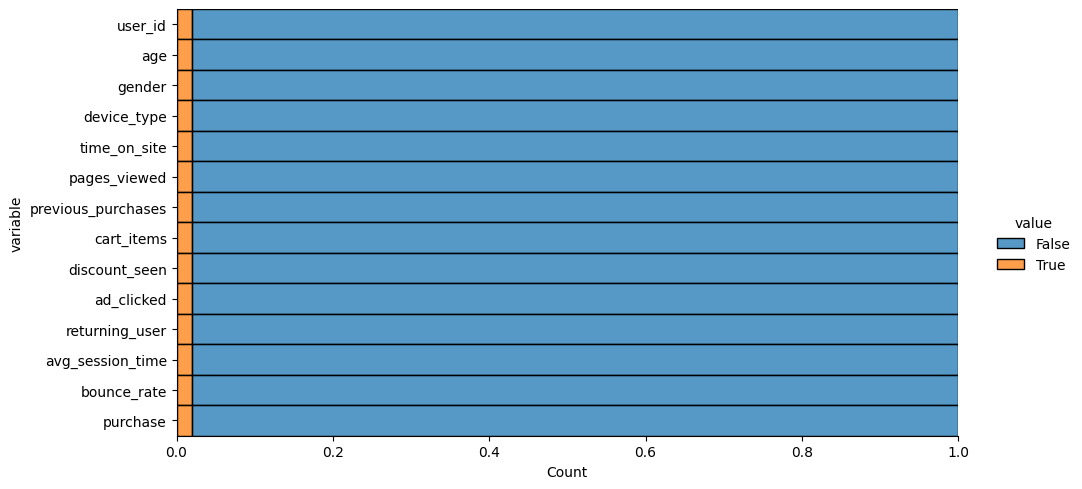

In [31]:
# Detecta valores nulos en el DataFrame.
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
# Muestra el gráfico generado.
plt.show()

In [22]:
#Estadísticas descriptivas
##Variables numéricas
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
user_id,7840.0,4003.135077,2307.898984,1.00,2011.7500,3998.00,6001.2500,8000.00
age,7840.0,38.595791,12.033928,18.00,28.0000,39.00,49.0000,59.00
time_on_site,7840.0,15.714673,8.362764,1.00,8.5200,15.74,22.8800,30.00
pages_viewed,7840.0,9.970026,5.425485,1.00,5.0000,10.00,15.0000,19.00
previous_purchases,7840.0,6.964158,4.281117,0.00,3.0000,7.00,11.0000,14.00
cart_items,7840.0,4.530230,2.865814,0.00,2.0000,5.00,7.0000,9.00
discount_seen,7840.0,0.502551,0.500025,0.00,0.0000,1.00,1.0000,1.00
ad_clicked,7840.0,0.502296,0.500027,0.00,0.0000,1.00,1.0000,1.00
returning_user,7840.0,0.509439,0.499943,0.00,0.0000,1.00,1.0000,1.00
avg_session_time,7840.0,15.794999,9.864556,0.57,7.7500,14.30,22.3925,44.75


In [23]:
##Variables categóricas
data.describe(include = 'object').transpose()

,count,unique,top,freq
gender,7840,2,Male,3931
device_type,7840,3,Mobile,4685


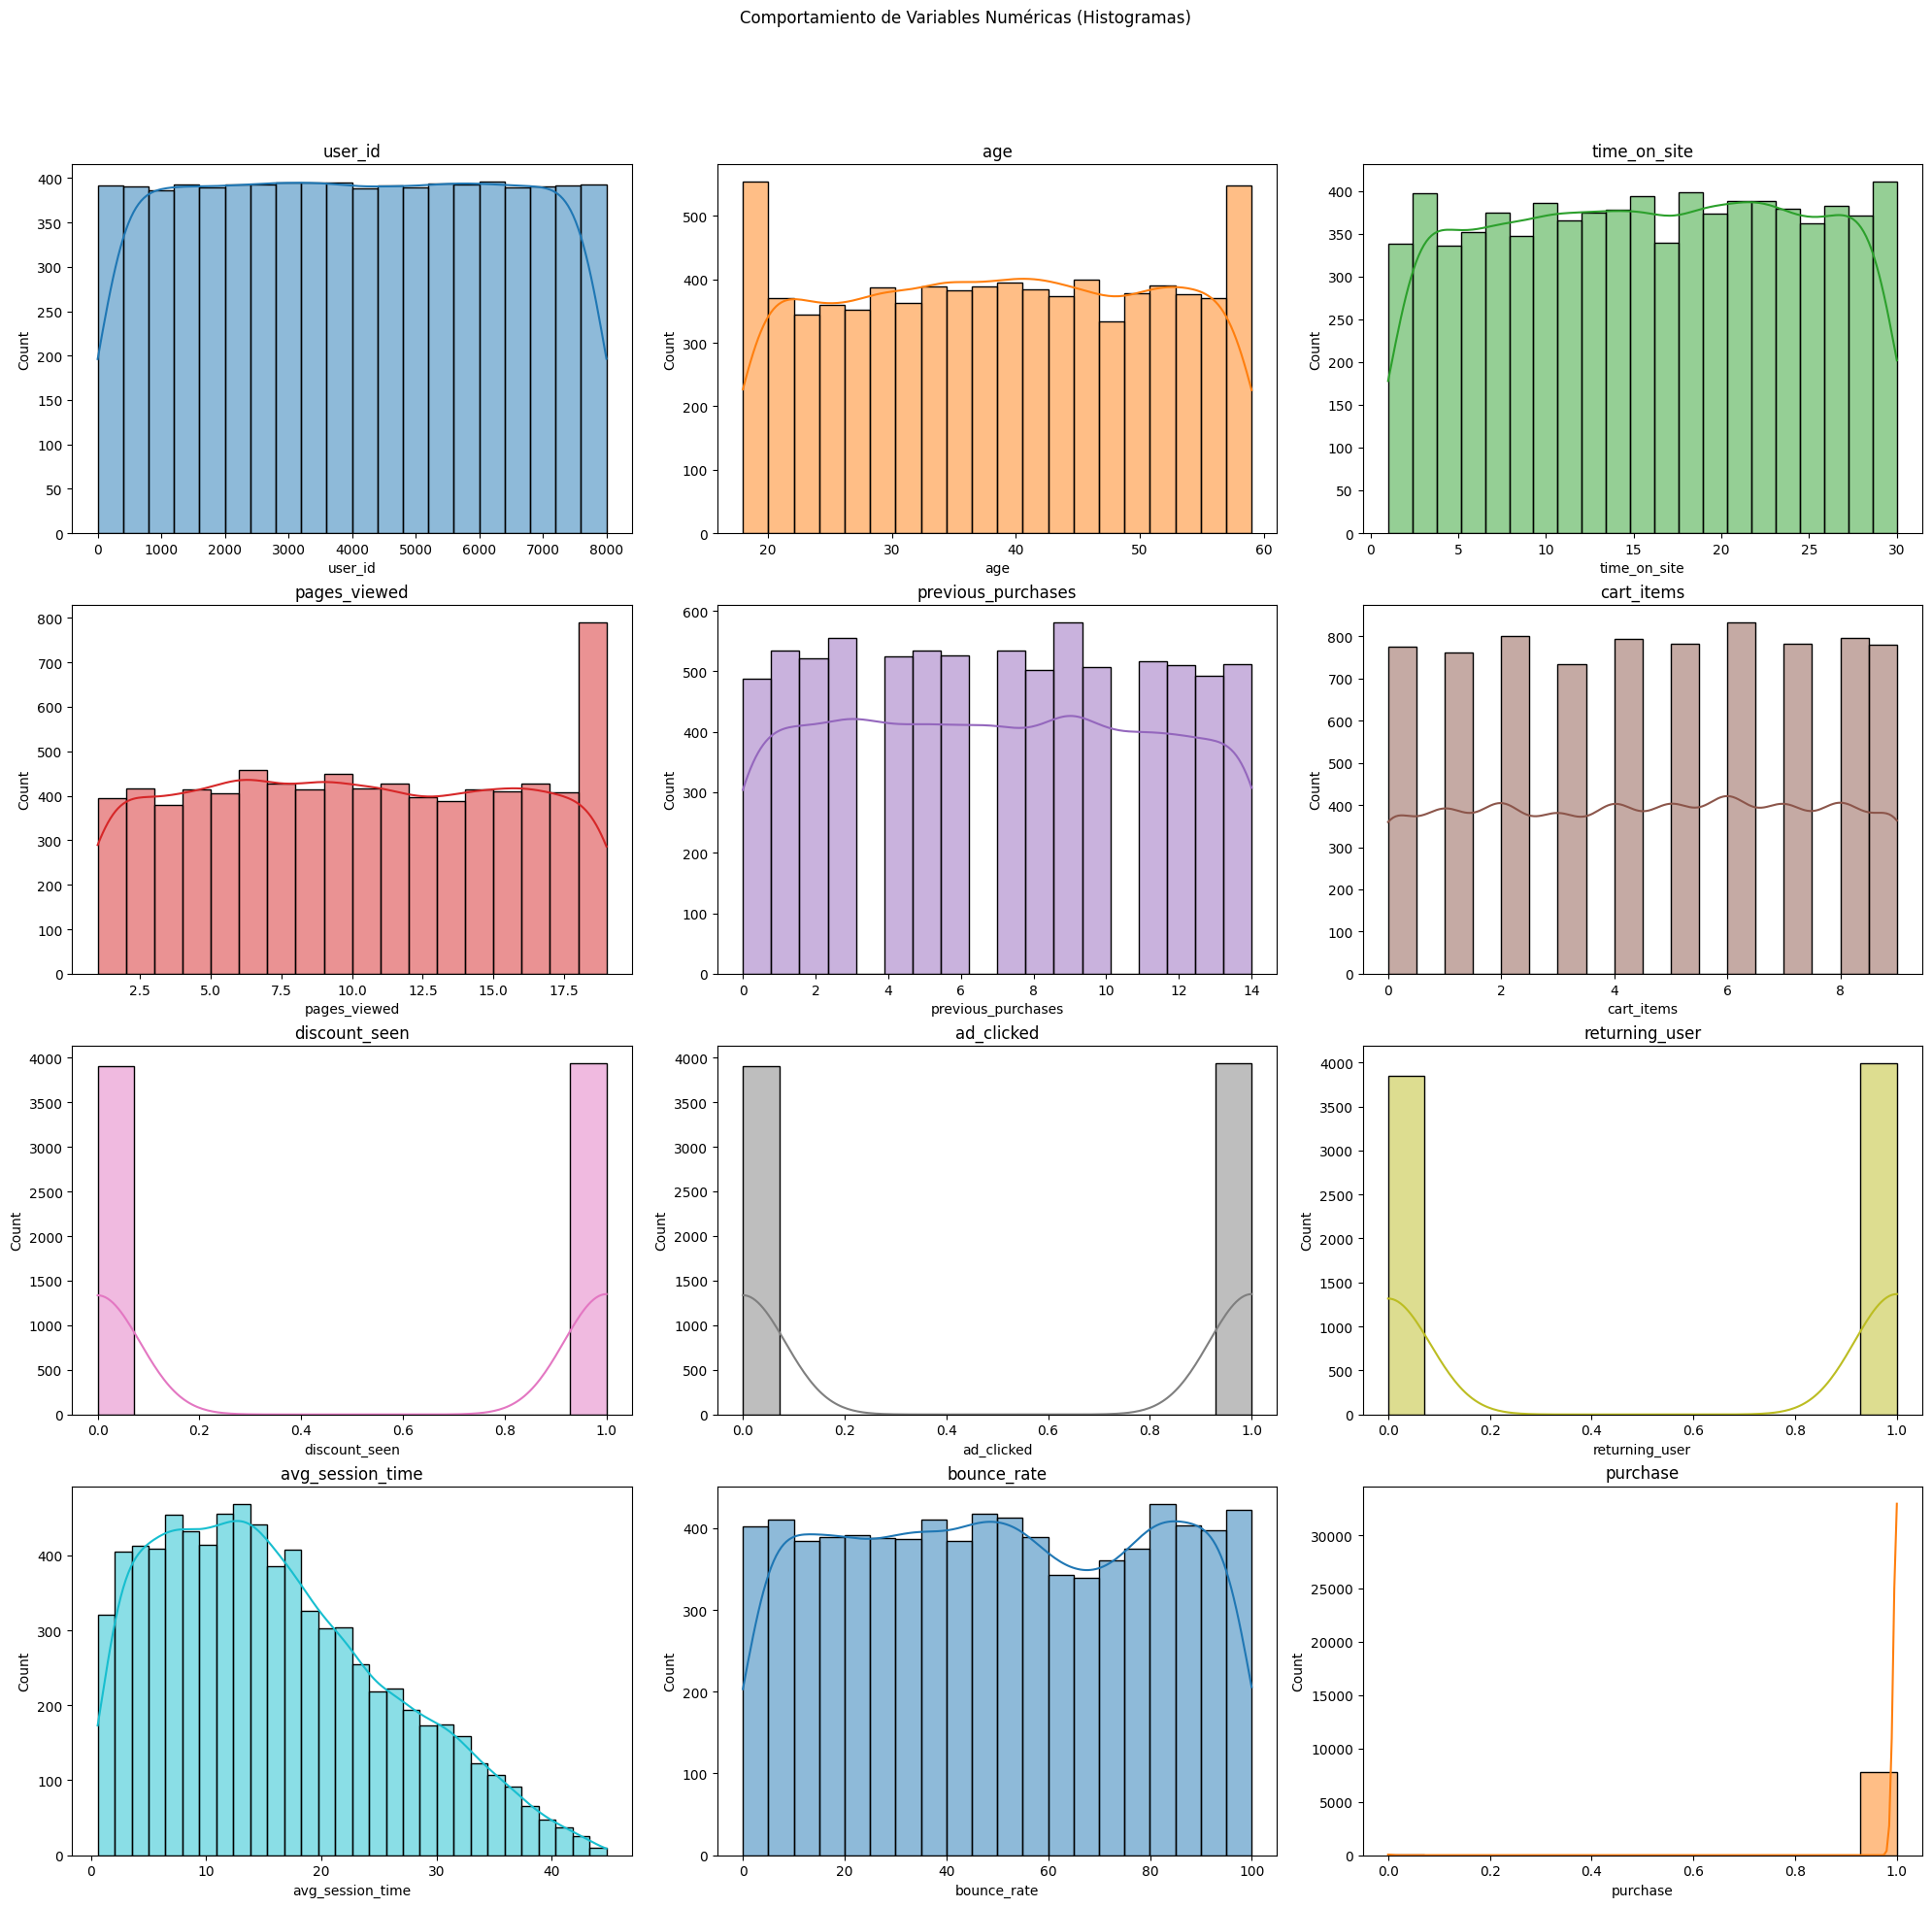

In [24]:
#Histogramas de Frecuencia
fig, ax = plt.subplots(4, 3, figsize = (20, 20))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns.to_list()
for i, col in enumerate(num_col):
    sb.histplot(data = data,
                x = col, kde = True, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas (Histogramas)')
plt.show()

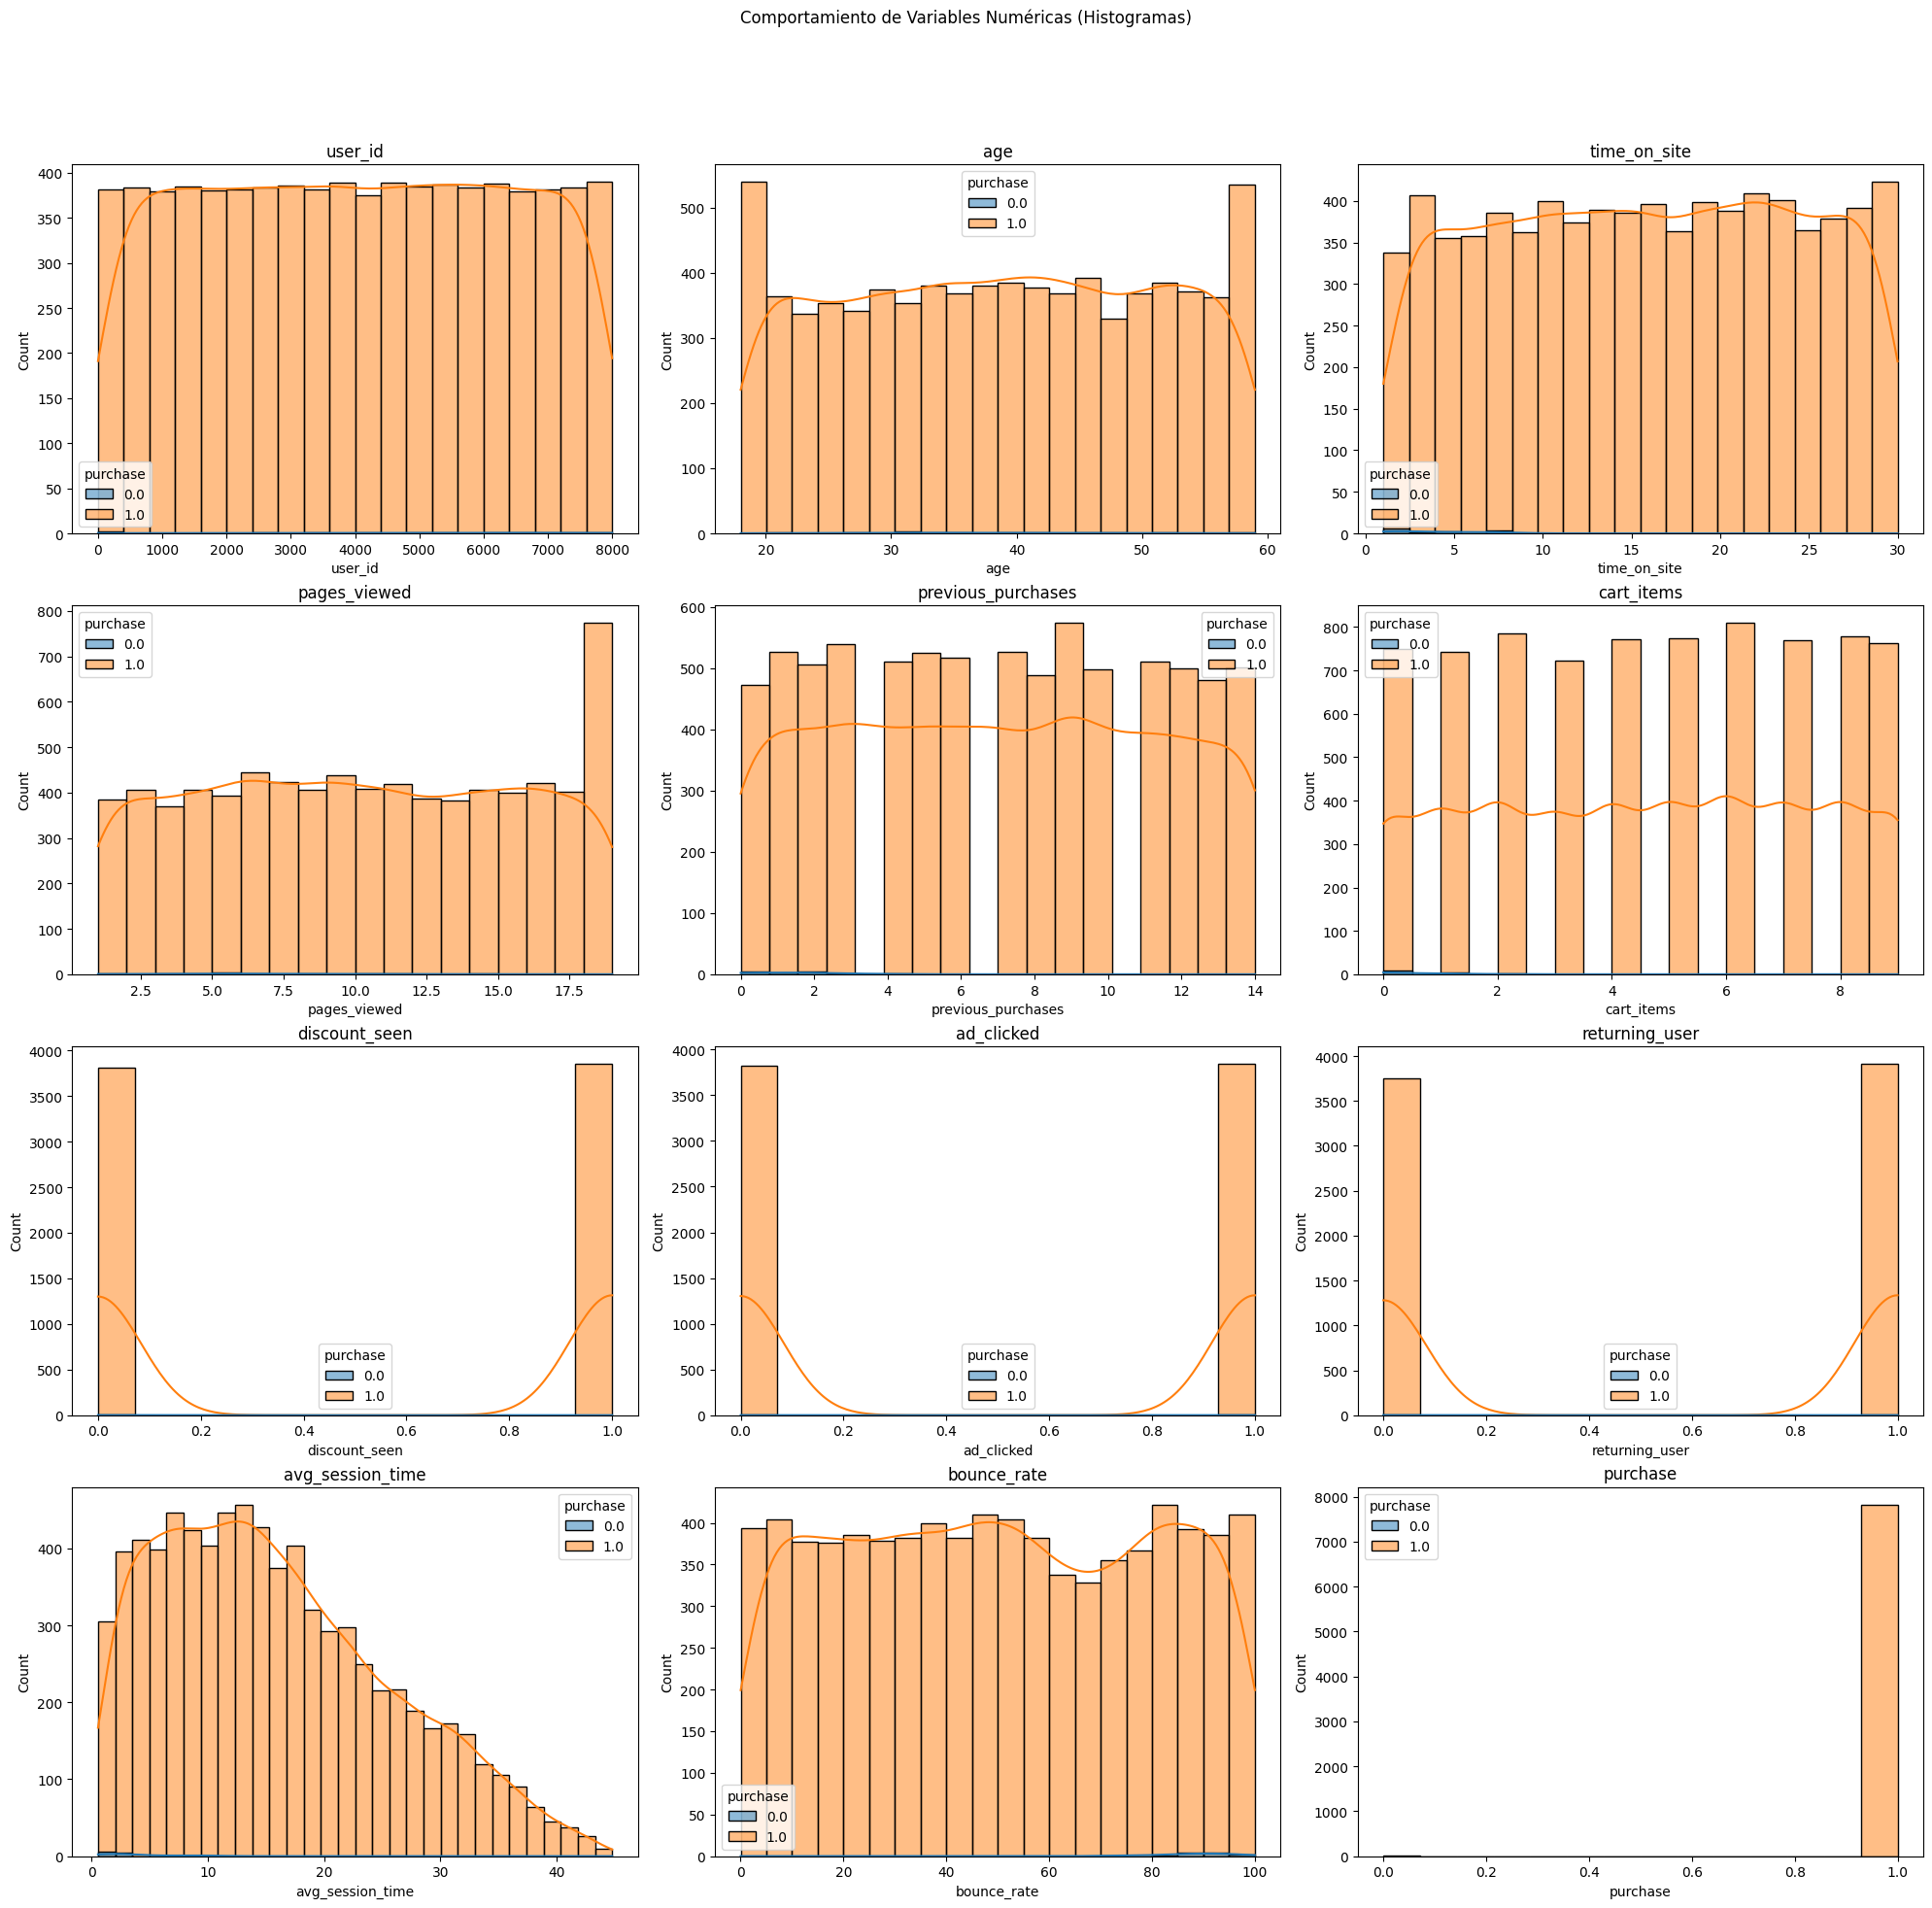

In [25]:
fig, ax = plt.subplots(4, 3, figsize = (20, 20))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns.to_list()
for i, col in enumerate(num_col):
    sb.histplot(data = data,
                x = col, kde = True, hue = data.purchase,
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas (Histogramas)')
plt.show()

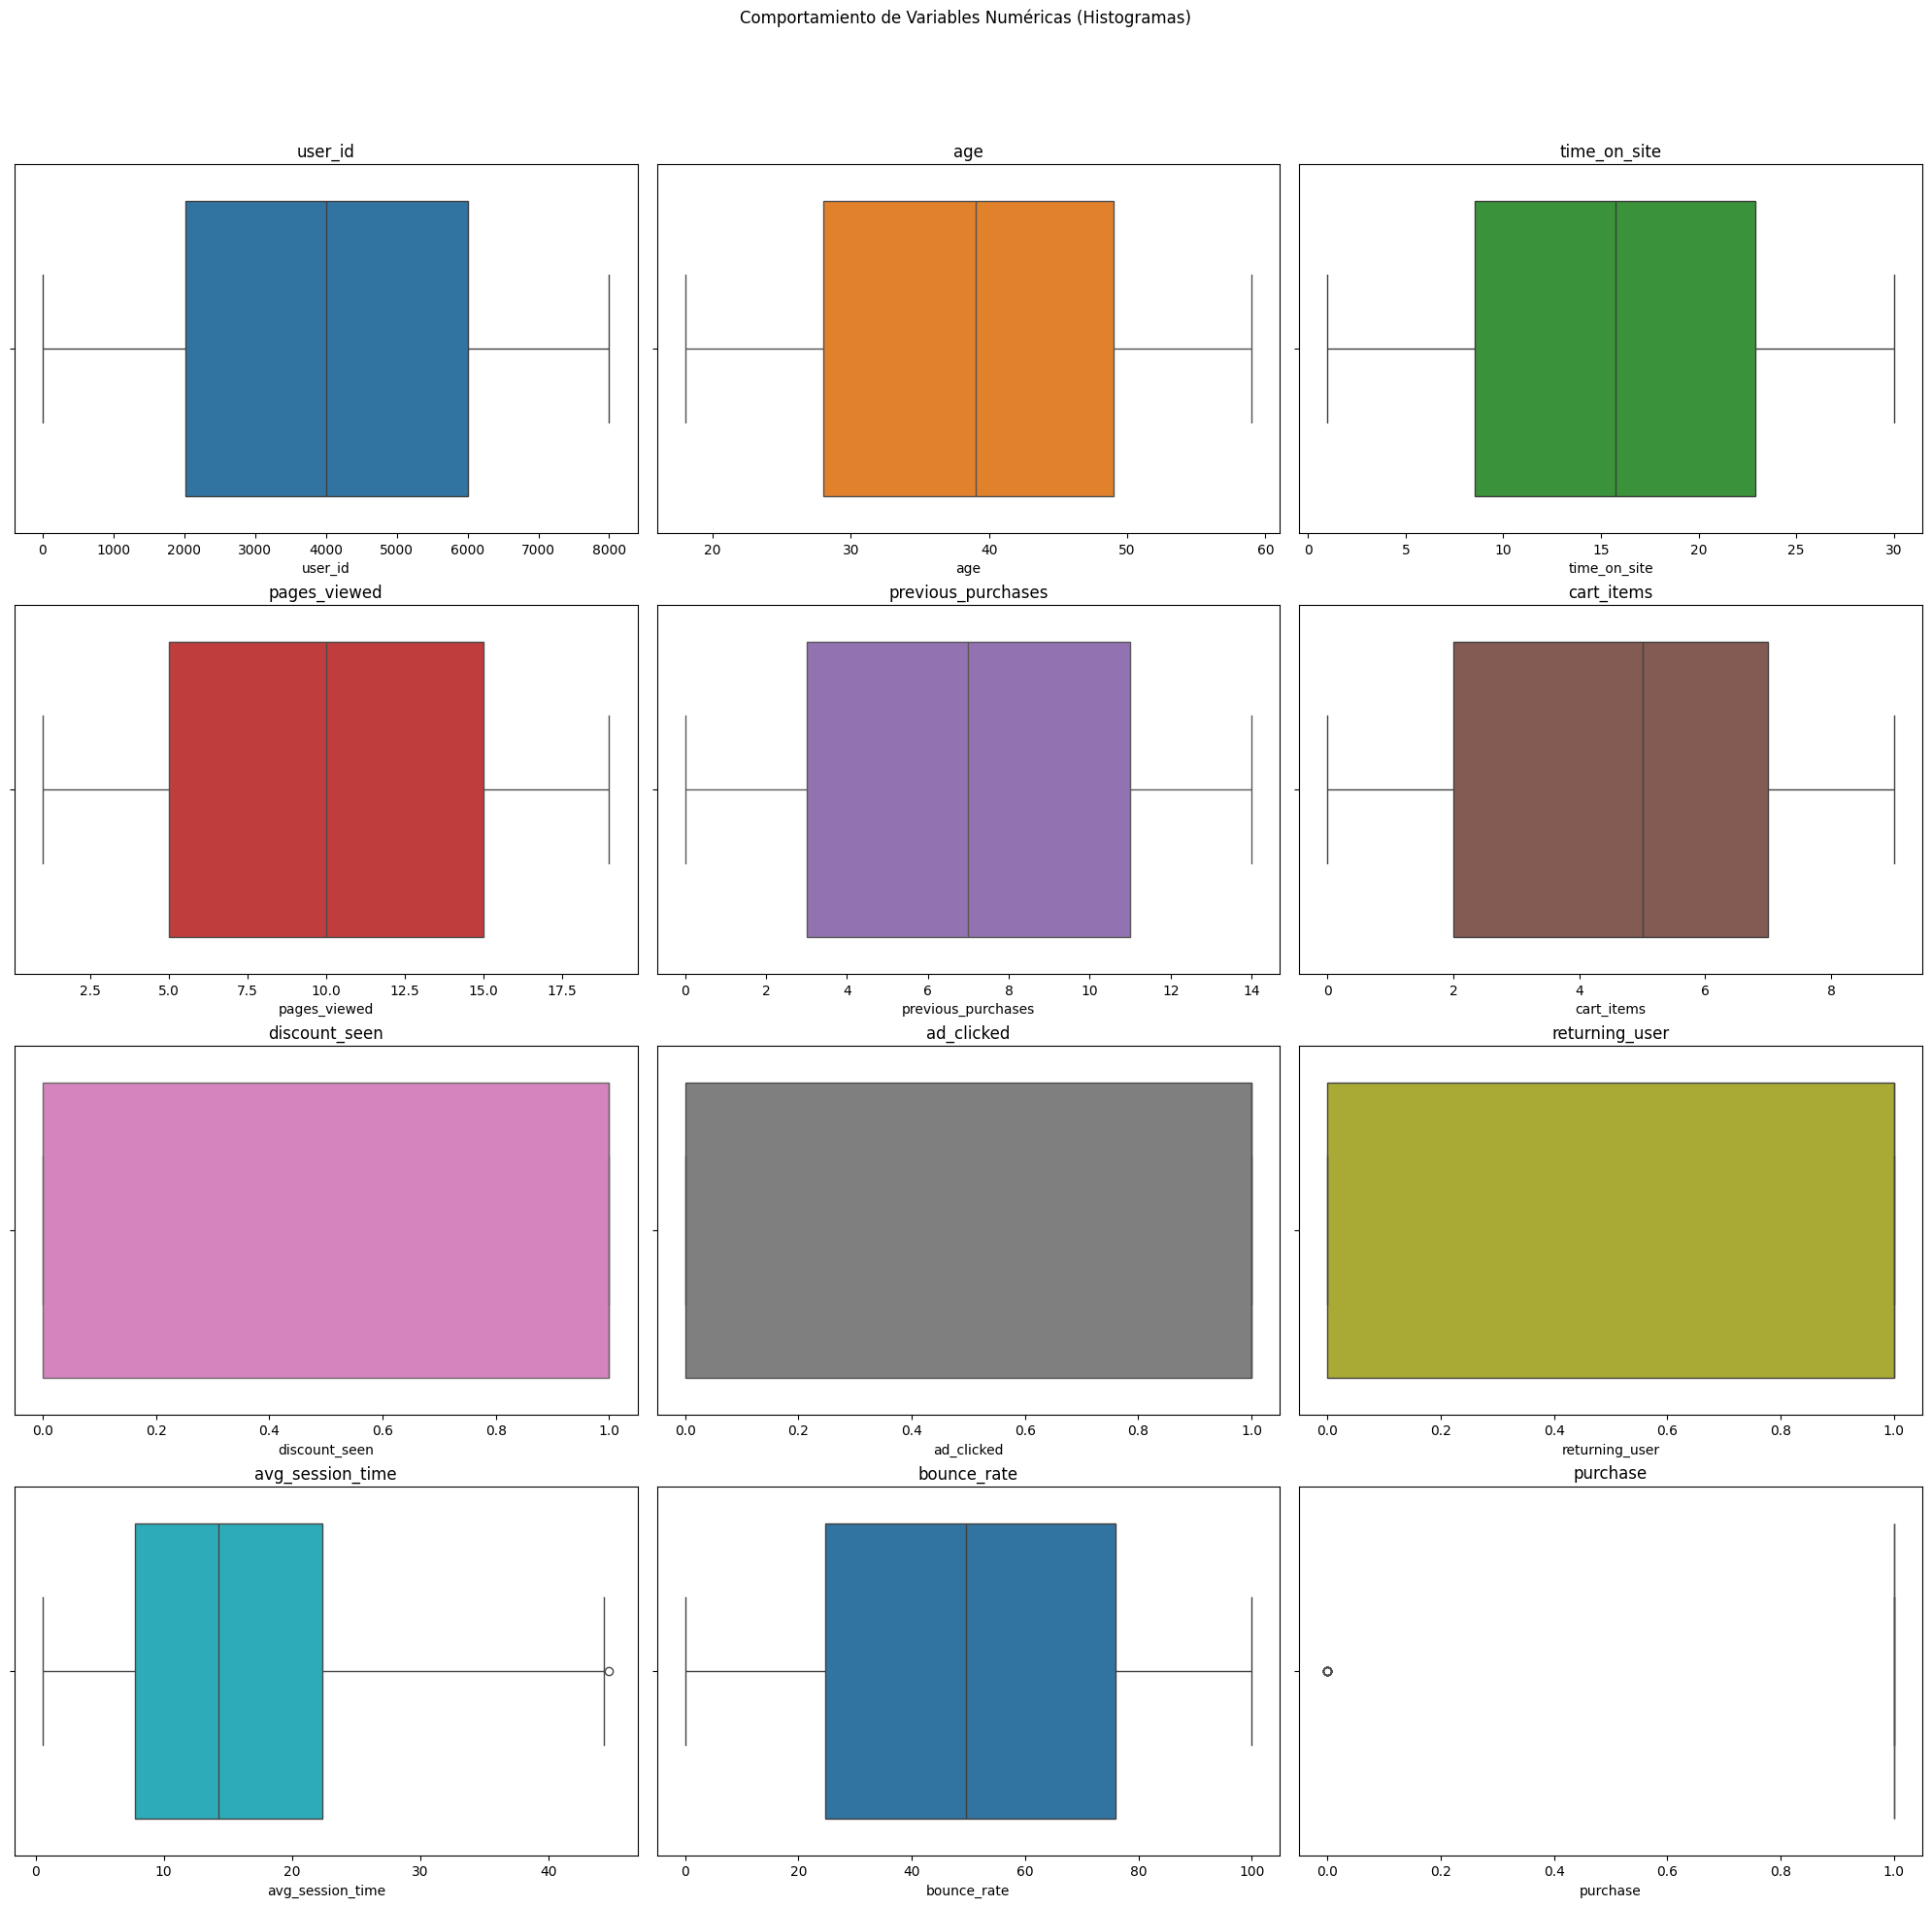

In [26]:
#Cajas y Bigotes
fig, ax = plt.subplots(4, 3, figsize = (20, 20))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns.to_list()
for i, col in enumerate(num_col):
    sb.boxplot(data = data,
                x = col, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas (Histogramas)')
plt.show()

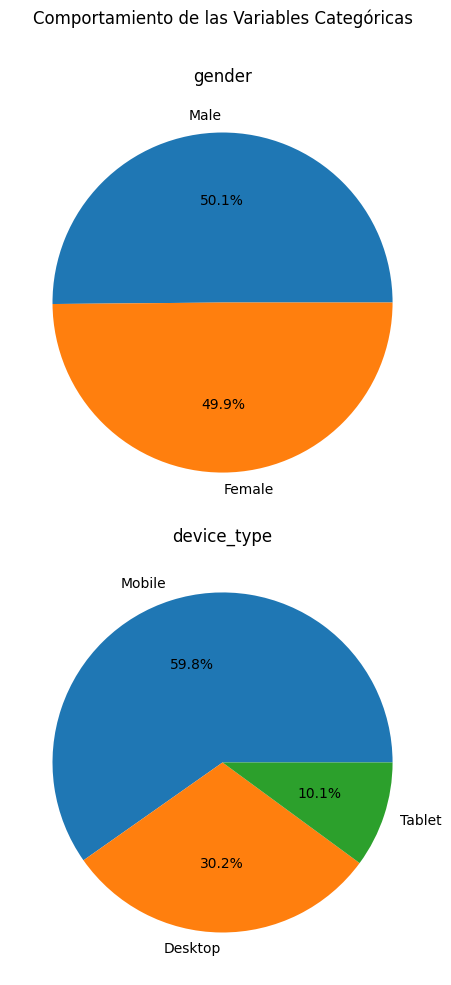

In [27]:
##Gráficos de tortas
fig, ax = plt.subplots(2, 1, figsize = (10, 10))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = "%0.1f%%")
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento de las Variables Categóricas")
plt.show()

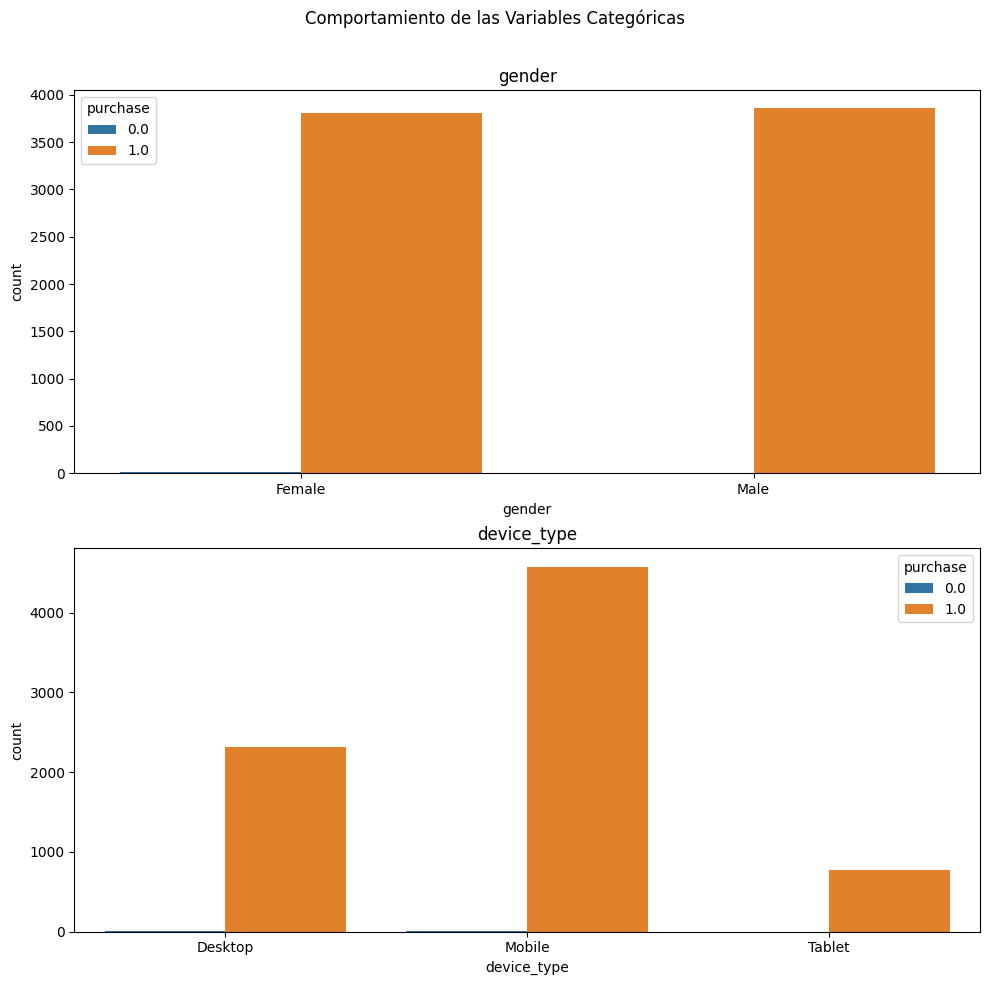

In [30]:
#Gráfico de categorías
fig, ax = plt.subplots(2, 1, figsize = (10, 10))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    sb.countplot(data = data, x = col, hue = data.purchase, ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento de las Variables Categóricas")
plt.show()

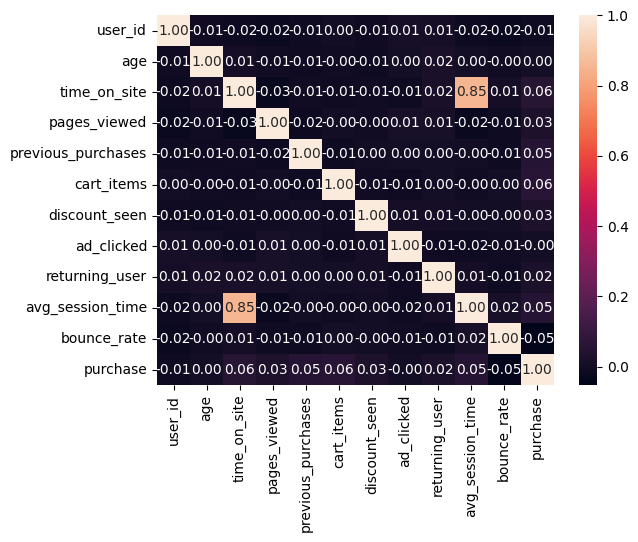

In [29]:
sb.heatmap(data = data.corr(numeric_only = True), annot = True, fmt = '0.2f')
plt.show(
)